# Module 6 Lab 1: Query Like an Analyst

**Name:** _Roey Kadur_  
**Repo URL:** _https://github.com/roee0910/cs82a-portfolio.git_


## Step 1: Load the CSVs and build the database

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

orders_df = pd.read_csv("store_orders.csv")
customers_df = pd.read_csv("store_customers.csv")

con = sqlite3.connect("store.db")
# if_exists="replace" lets you re-run the notebook (Restart & Run All) without a "table already exists" error
orders_df.to_sql("orders", con, index=False, if_exists="replace")
customers_df.to_sql("customers", con, index=False, if_exists="replace")

pd.read_sql("SELECT name FROM sqlite_master", con)

,name
0,orders
1,customers


## Step 2: First look

In [2]:
pd.read_sql("SELECT * FROM orders LIMIT 5", con)

,order_id,customer_id,product,category,amount,order_date
0,5000,4,paper,office,14.09,2026-05-25
1,5001,15,planner,office,51.86,2026-05-08
2,5002,34,shelf,furniture,116.25,2026-06-03
3,5003,2,granola,snacks,19.72,2026-05-19
4,5004,17,monitor,electronics,284.80,2026-05-10


## Step 3: Filter and sort

All orders over 100 USD, highest amount first. The top row is the seeded 499 USD order.

In [3]:
big_orders = pd.read_sql("""
    SELECT *
    FROM orders
    WHERE amount > 100
    ORDER BY amount DESC
""", con)

print(len(big_orders), "orders over $100")
big_orders.head(10)

84 orders over $100


,order_id,customer_id,product,category,amount,order_date
0,5153,20,dock,electronics,499.00,2026-05-25
1,5140,30,headset,electronics,295.36,2026-05-26
2,5047,901,headset,electronics,293.79,2026-05-15
3,5150,903,monitor,electronics,293.35,2026-06-06
4,5014,6,monitor,electronics,287.83,2026-05-22
5,5113,4,headset,electronics,286.65,2026-05-15
6,5034,29,headset,electronics,286.36,2026-05-14
7,5149,8,headset,electronics,286.30,2026-05-05
8,5004,17,monitor,electronics,284.80,2026-05-10
9,5174,11,headset,electronics,277.24,2026-05-26


## Step 4: Aggregate by category

In [4]:
pd.read_sql("""
    SELECT category,
           COUNT(*)    AS n,
           AVG(amount) AS avg_amount
    FROM orders
    GROUP BY category
    ORDER BY avg_amount DESC
""", con)

,category,n,avg_amount
0,electronics,60,190.569500
1,furniture,46,146.251522
2,office,51,30.132549
3,snacks,43,14.619767


**Electronics** earns the most per order, at about 190.57 USD on average, well ahead of furniture (about 146.25 USD), while office supplies and snacks average only about 30 USD and 15 USD.

## Step 5: Join for spend by city

The data dictionary names `customer_id` as the key shared by both tables.

In [5]:
city_spend = pd.read_sql("""
    SELECT c.city,
           SUM(o.amount) AS total_spend
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    GROUP BY c.city
    ORDER BY total_spend DESC
""", con)

city_spend

,city,total_spend
0,Los Angeles,5862.99
1,Culver City,5316.88
2,Santa Monica,4017.93
3,Inglewood,2718.25
4,Torrance,1037.25
5,Venice,462.36


## Step 6: The row-count audit

In [6]:
n_orders = pd.read_sql("SELECT COUNT(*) AS n FROM orders", con).iloc[0, 0]

n_joined = pd.read_sql("""
    SELECT COUNT(*) AS n
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
""", con).iloc[0, 0]

print("Rows in orders:         ", n_orders)
print("Rows after the join:    ", n_joined)
print("Rows lost in the join:  ", n_orders - n_joined)

# Which customer_ids in orders have no match in customers?
pd.read_sql("""
    SELECT o.customer_id, COUNT(*) AS n_orders, SUM(o.amount) AS total_amount
    FROM orders o
    LEFT JOIN customers c ON o.customer_id = c.customer_id
    WHERE c.customer_id IS NULL
    GROUP BY o.customer_id
""", con)

Rows in orders:          200
Rows after the join:     195
Rows lost in the join:   5


,customer_id,n_orders,total_amount
0,900,1,34.51
1,901,1,293.79
2,902,1,16.68
3,903,1,293.35
4,904,1,273.16


The `orders` table has 200 rows but the join produced only 195. An inner `JOIN` keeps a row only when `customer_id` exists in both tables, and 5 orders carry a `customer_id` (such as 901) that matches no customer, so they silently drop out. This means the city totals in Step 5 undercount overall sales by the amount of those 5 orders, and I would raise it with whoever owns the data.

## Step 7: Chart a query result

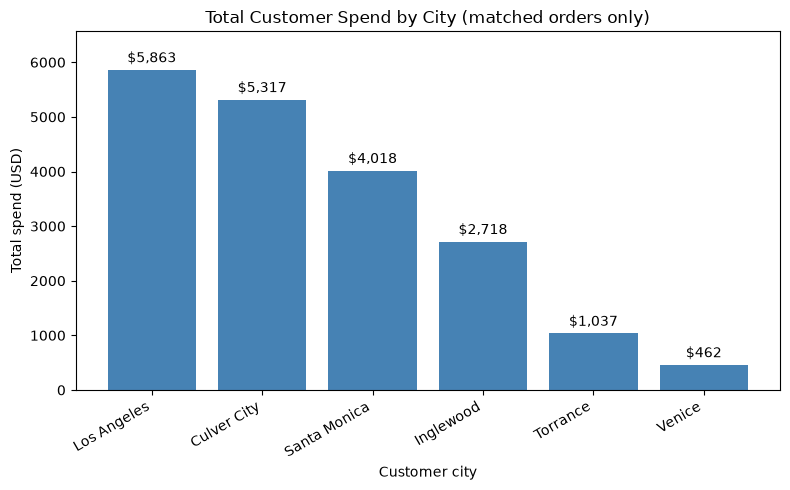

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(city_spend["city"], city_spend["total_spend"], color="steelblue")
ax.bar_label(bars, labels=[f"${v:,.0f}" for v in city_spend["total_spend"]], padding=3)
ax.set_title("Total Customer Spend by City (matched orders only)")
ax.set_xlabel("Customer city")
ax.set_ylabel("Total spend (USD)")
ax.set_ylim(0, city_spend["total_spend"].max() * 1.12)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Step 8: My own question

**Question:** Which city has the highest *average order value*, and is it driven by a lot of orders or by a few expensive ones?

In [8]:
pd.read_sql("""
    SELECT c.city,
           COUNT(*)      AS n_orders,
           AVG(o.amount) AS avg_order_value
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    GROUP BY c.city
    ORDER BY avg_order_value DESC
""", con)

,city,n_orders,avg_order_value
0,Los Angeles,46,127.456304
1,Inglewood,27,100.675926
2,Santa Monica,42,95.665000
3,Culver City,58,91.670345
4,Torrance,14,74.089286
5,Venice,8,57.795000


**Answer:** Los Angeles has the highest average order value at about 127.46 USD across 46 orders. Its lead comes from higher-priced orders rather than volume alone: Culver City has more orders (58) but a lower average (about 91.67 USD). Venice is at the other end with only 8 orders averaging about 57.80 USD.

## Step 9: Ethics note and safe push

Before sharing publicly I would remove `name` entirely (and `customer_id` if it could be linked back to a person elsewhere) and share only aggregates like city totals or category averages, because names are directly identifying. I would also keep aggregates from tiny groups out of public view: a city with only a few customers could still point to specific individuals. This notebook never prints the full `customers` table, and I will push only `module6_lab.ipynb`, never `store.db` or the CSV files (a `.gitignore` containing `*.db` and `*.csv` helps).

In [10]:
con.close()